In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ApexPlanet_DataAnalytics_Dataset.xlsx to ApexPlanet_DataAnalytics_Dataset.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("ApexPlanet_DataAnalytics_Dataset.xlsx")
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB


In [ ]:
df.describe()

,Age,Quantity,Unit_Price,Total_Sales
count,980.000000,1000.000000,1000.000000,1000.000000
mean,41.360204,5.435000,25486.783410,139399.439650
std,13.822597,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,54.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,20
Gender,0
City,13
Product,0
Category,0
Quantity,0


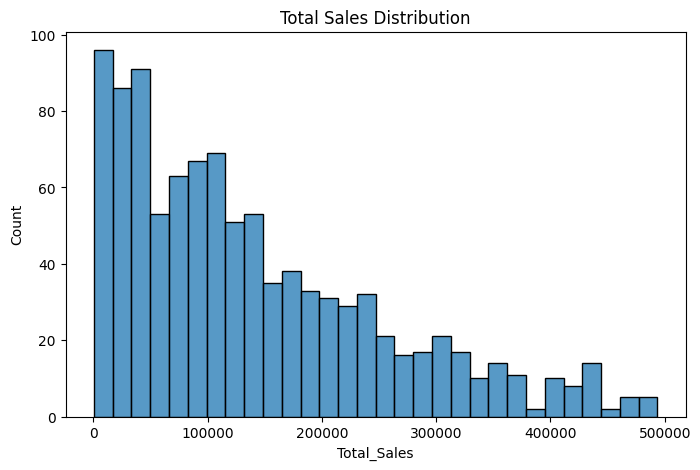

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Total_Sales"], bins=30)

plt.title("Total Sales Distribution")

plt.show()

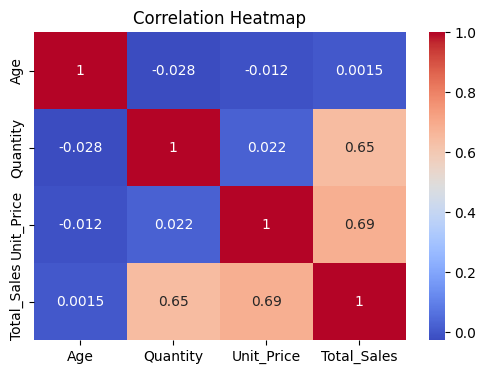

In [ ]:
plt.figure(figsize=(6,4))

corr = df[['Age','Quantity','Unit_Price','Total_Sales']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
import sqlite3

conn = sqlite3.connect('sales.db')

df.to_sql(
    'sales_data',
    conn,
    if_exists='replace',
    index=False
)

1000

In [ ]:
query = """
SELECT Product,
SUM(Total_Sales) AS Revenue
FROM sales_data
GROUP BY Product
ORDER BY Revenue DESC
LIMIT 5
"""

pd.read_sql(query, conn)

,Product,Revenue
0,Laptop,25443008.51
1,Mobile,25335573.19
2,Book,25031689.40
3,Rice,22231711.28
4,Chair,21521561.48


In [ ]:
query = """
SELECT City,
SUM(Total_Sales) AS Total_Revenue
FROM sales_data
GROUP BY City
ORDER BY Total_Revenue DESC
"""

pd.read_sql(query, conn)

,City,Total_Revenue
0,Patna,19285966.89
1,Kolkata,18884349.57
2,Bengaluru,18773574.32
3,Mumbai,18757050.17
4,Hyderabad,17166766.87
5,Delhi,16097079.00
6,Pune,14513175.90
7,Gaya,14380859.39
8,None,1540617.54


In [ ]:
query = """
SELECT Category,
SUM(Total_Sales) AS Revenue
FROM sales_data
GROUP BY Category
ORDER BY Revenue DESC
"""

pd.read_sql(query, conn)

,Category,Revenue
0,Electronics,50778581.70
1,Education,25031689.40
2,Grocery,22231711.28
3,Furniture,21521561.48
4,Fashion,19835895.79
